# NSGD vs LSTM-PPO — Evaluation Comparison

Compares the two agents over the first 90 minutes of their evaluation runs.

**Files expected:**
- `logs/nsgd/samples.csv` — NSGD evaluation samples
- `logs/lstm_ppo/samples.csv` — LSTM-PPO evaluation samples

If your LSTM-PPO data lives elsewhere, edit `LSTM_PPO_DIR` in the setup cell.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.8,
})

NSGD_DIR = 'logs/nsgd_constant_poss_7_1000K_eval'
LSTM_PPO_DIR = 'logs/nsgd_last_final_evaluate_6_hours'
OUT_DIR = 'logs/comparison'
os.makedirs(OUT_DIR, exist_ok=True)

WINDOW_MINUTES = 90
WINDOW_SECONDS = WINDOW_MINUTES * 60

COLOR_NSGD = '#2196F3'
COLOR_PPO = '#FF6F00'

# Load both samples files
nsgd_samples = pd.read_csv(f'{NSGD_DIR}/samples.csv')
ppo_samples = pd.read_csv(f'{LSTM_PPO_DIR}/samples.csv')

# Trim to first 90 minutes (each agent normalized to its own start time)
def trim_window(df):
    df = df.copy()
    start = df['timestamp'].min()
    df['minutes_from_start'] = (df['timestamp'] - start) / 60
    return df[df['minutes_from_start'] <= WINDOW_MINUTES].reset_index(drop=True)

nsgd = trim_window(nsgd_samples)
ppo = trim_window(ppo_samples)

print(f'NSGD samples in first {WINDOW_MINUTES} min: {len(nsgd)}')
print(f'LSTM-PPO samples in first {WINDOW_MINUTES} min: {len(ppo)}')

NSGD samples in first 90 min: 180
LSTM-PPO samples in first 90 min: 180


## Throughput

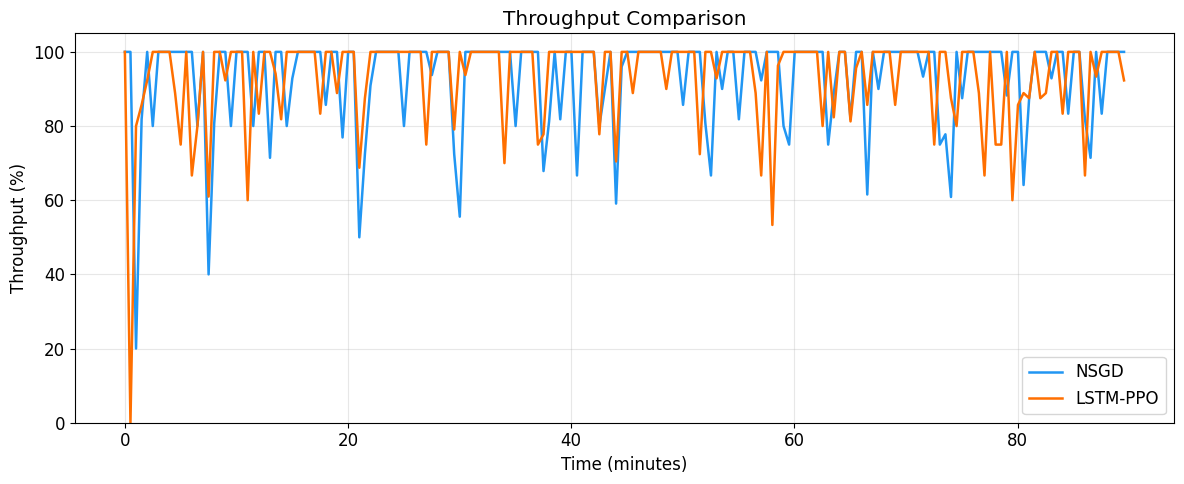

NSGD mean:     93.13%
LSTM-PPO mean: 93.50%


In [17]:
fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['throughput'],
        color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['throughput'],
        color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Throughput (%)')
ax.set_title('Throughput Comparison')
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/comp_throughput.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NSGD mean:     {nsgd["throughput"].mean():.2f}%')
print(f'LSTM-PPO mean: {ppo["throughput"].mean():.2f}%')

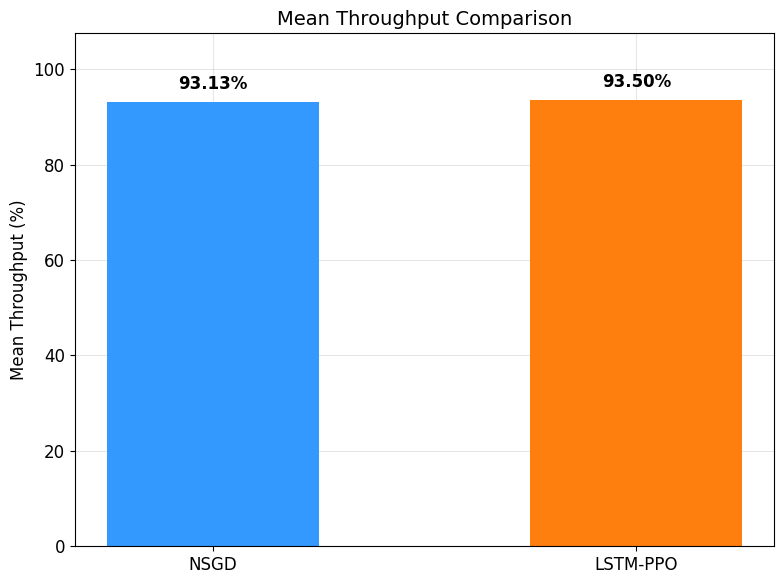

In [18]:
import matplotlib.pyplot as plt

# 1. Calculate the mean throughputs
nsgd_mean_throughput = nsgd["throughput"].mean()
ppo_mean_throughput = ppo["throughput"].mean()

# 2. Set up the data for the plot
models = ['NSGD', 'LSTM-PPO']
means = [nsgd_mean_throughput, ppo_mean_throughput]
colors = ['#3399FF', '#FF7F0E']  # Matching the requested blue and orange

# 3. Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(models, means, color=colors, width=0.5)

# 4. Apply formatting and labels
plt.title('Mean Throughput Comparison', fontsize=14)
plt.ylabel('Mean Throughput (%)', fontsize=12)

# Grid styling
plt.grid(axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
plt.gca().set_axisbelow(True)

# Give the y-axis a little extra room at the top so the text labels fit nicely
plt.ylim(0, max(means) * 1.15)

# 5. Add the exact percentage values on top of the bars
for bar in bars:
    yval = bar.get_height()
    # Adding the .2f% formatting inside the text label
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(means) * 0.02), 
             f"{yval:.2f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

# Display the plot
plt.tight_layout()
plt.show()

## Total Rejected Function Calls (cumulative)

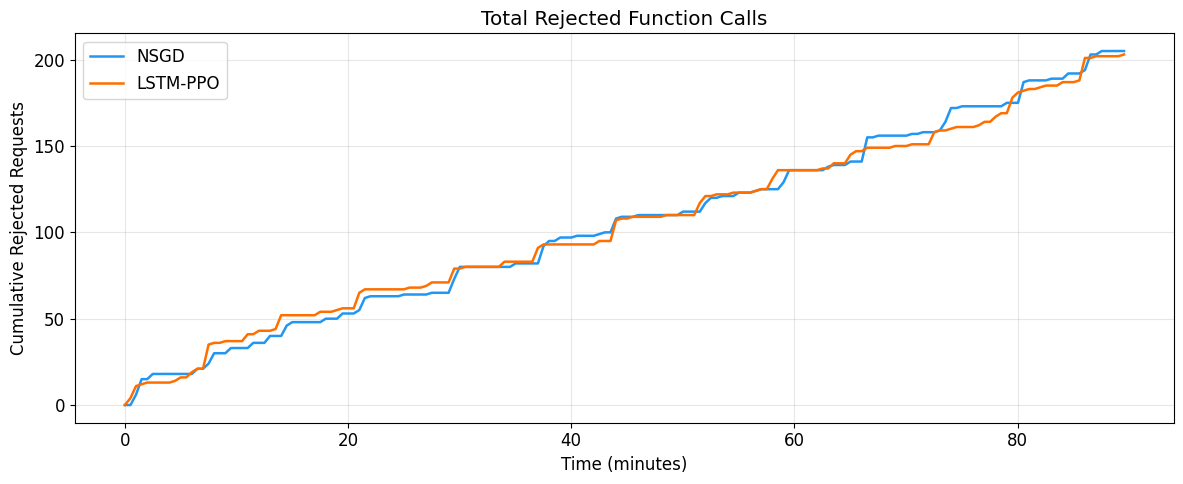

NSGD total rejections:     205
LSTM-PPO total rejections: 203


In [19]:
nsgd['cum_rejections'] = nsgd['proxy_rejections'].cumsum()
ppo['cum_rejections'] = ppo['proxy_rejections'].cumsum()

fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['cum_rejections'],
        color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['cum_rejections'],
        color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Cumulative Rejected Requests')
ax.set_title('Total Rejected Function Calls')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/comp_rejections.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NSGD total rejections:     {int(nsgd["cum_rejections"].iloc[-1])}')
print(f'LSTM-PPO total rejections: {int(ppo["cum_rejections"].iloc[-1])}')

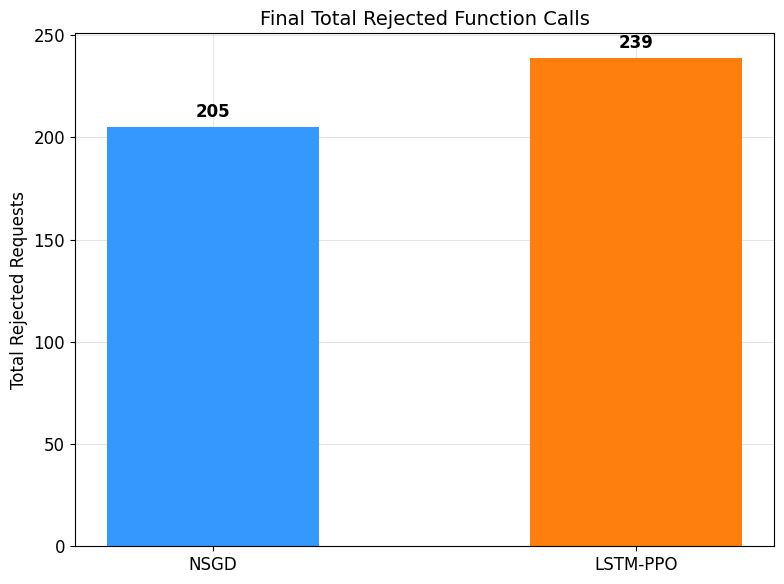

In [21]:
import matplotlib.pyplot as plt

# 1. Extract the final total from the end of the cumulative series
nsgd_final_total = nsgd['cum_rejections'].iloc[-1]
ppo_final_total = ppo['cum_rejections'].iloc[-1]

# 2. Set up the data for the plot
models = ['NSGD', 'LSTM-PPO']
totals = [nsgd_final_total, ppo_final_total]
colors = ['#3399FF', '#FF7F0E']  # Matching the requested blue and orange

# 3. Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(models, totals, color=colors, width=0.5)

# 4. Apply formatting and labels
plt.title('Final Total Rejected Function Calls', fontsize=14)
plt.ylabel('Total Rejected Requests', fontsize=12)

# Grid styling
plt.grid(axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
plt.gca().set_axisbelow(True)

# 5. Add the exact numerical values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 3, int(yval), 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Display the plot
plt.tight_layout()
plt.show()

## NSGD Cost

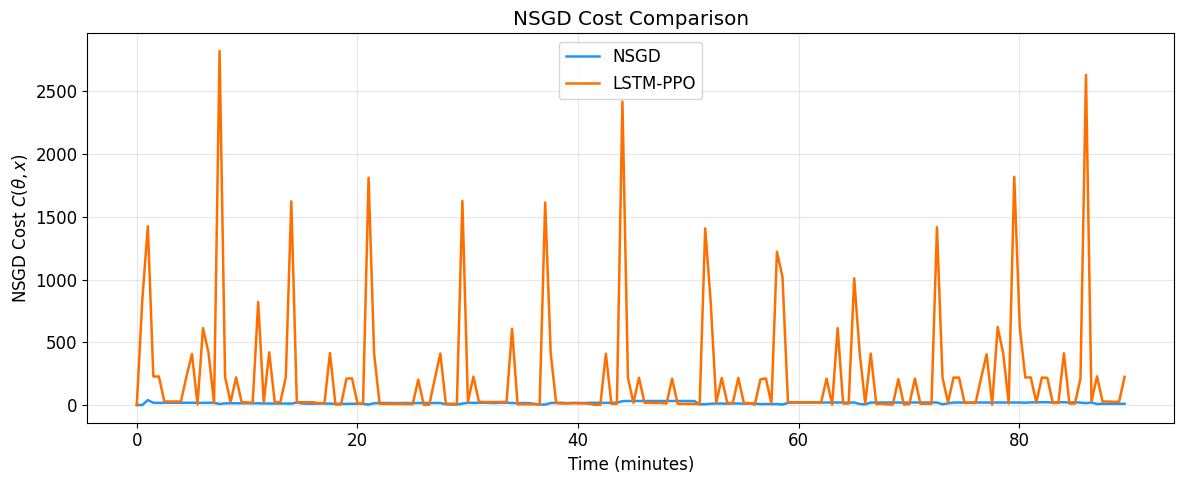

NSGD mean cost:     18.53
LSTM-PPO mean cost: 242.60


In [20]:
fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['nsgd_cost'],
        color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['nsgd_cost'],
        color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('NSGD Cost $C(\\theta, x)$')
ax.set_title('NSGD Cost Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/comp_nsgd_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NSGD mean cost:     {nsgd["nsgd_cost"].mean():.2f}')
print(f'LSTM-PPO mean cost: {ppo["nsgd_cost"].mean():.2f}')

## LSTM-PPO Reward

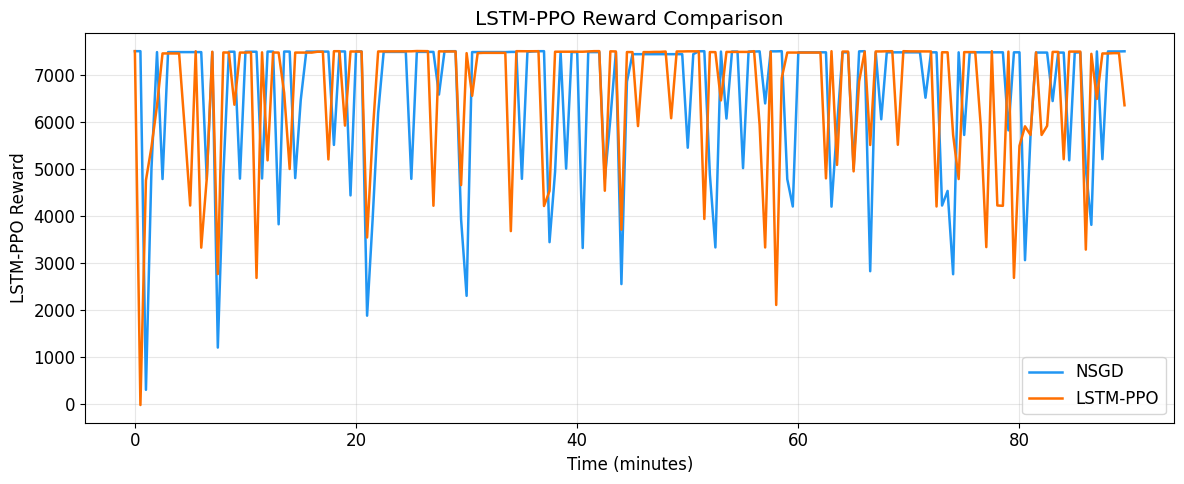

NSGD mean reward:     6612.13
LSTM-PPO mean reward: 6661.68


In [21]:
fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['lstm_ppo_reward'],
        color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['lstm_ppo_reward'],
        color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('LSTM-PPO Reward')
ax.set_title('LSTM-PPO Reward Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/comp_lstm_ppo_reward.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NSGD mean reward:     {nsgd["lstm_ppo_reward"].mean():.2f}')
print(f'LSTM-PPO mean reward: {ppo["lstm_ppo_reward"].mean():.2f}')

## CPU Utilization

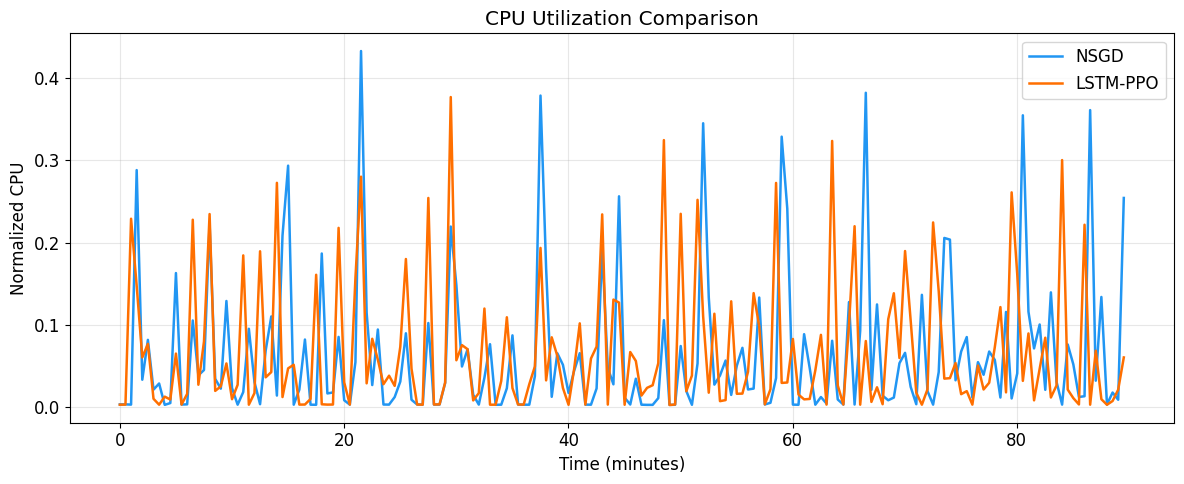

NSGD mean CPU:     0.0652
LSTM-PPO mean CPU: 0.0679


In [22]:
fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['avg_cpu'],
        color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['avg_cpu'],
        color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Normalized CPU')
ax.set_title('CPU Utilization Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/comp_cpu.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NSGD mean CPU:     {nsgd["avg_cpu"].mean():.4f}')
print(f'LSTM-PPO mean CPU: {ppo["avg_cpu"].mean():.4f}')

## Memory Utilization

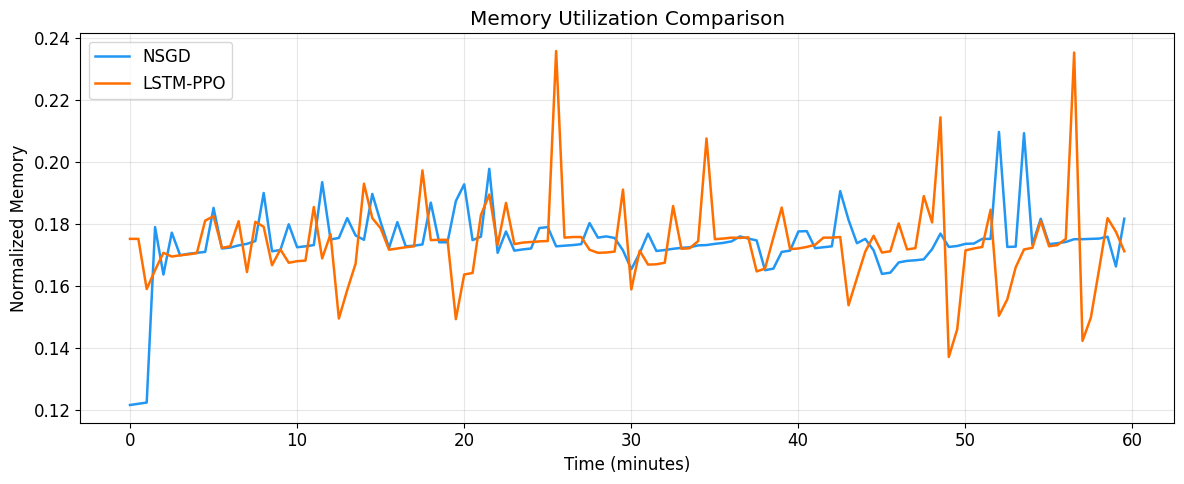

NSGD mean memory:     0.1741
LSTM-PPO mean memory: 0.1737


In [8]:
fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['avg_mem'],
        color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['avg_mem'],
        color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Normalized Memory')
ax.set_title('Memory Utilization Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/comp_memory.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NSGD mean memory:     {nsgd["avg_mem"].mean():.4f}')
print(f'LSTM-PPO mean memory: {ppo["avg_mem"].mean():.4f}')

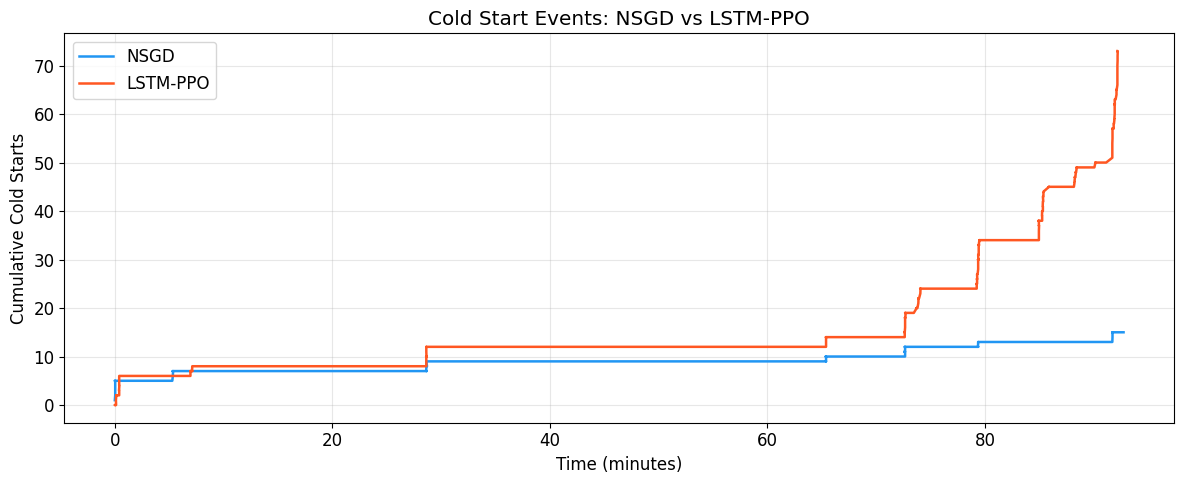

Duration: 92.7 minutes

NSGD:     1,318 requests, 15 cold starts (1.14%)
LSTM-PPO: 1,316 requests, 73 cold starts (5.55%)


In [9]:
nsgd_req = pd.read_csv('logs/nsgd_constant_poss_7_eval/request_log.csv')
ppo_req = pd.read_csv('logs/rl_eval/request_log.csv')

# Normalize to elapsed minutes since each run's start
nsgd_req['minutes'] = (nsgd_req['timestamp'] - nsgd_req['timestamp'].min()) / 60
ppo_req['minutes'] = (ppo_req['timestamp'] - ppo_req['timestamp'].min()) / 60

# Trim to shorter run for fair comparison
max_minutes = min(nsgd_req['minutes'].max(), ppo_req['minutes'].max())
nsgd_req = nsgd_req[nsgd_req['minutes'] <= max_minutes].copy()
ppo_req = ppo_req[ppo_req['minutes'] <= max_minutes].copy()

# Cumulative cold start counts
nsgd_req['cum_cold'] = nsgd_req['is_cold_start'].astype(int).cumsum()
ppo_req['cum_cold'] = ppo_req['is_cold_start'].astype(int).cumsum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(nsgd_req['minutes'], nsgd_req['cum_cold'], color='#2196F3', label='NSGD')
ax.plot(ppo_req['minutes'], ppo_req['cum_cold'], color='#FF5722', label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Cumulative Cold Starts')
ax.set_title('Cold Start Events: NSGD vs LSTM-PPO')
ax.legend()
plt.tight_layout()
plt.savefig('logs/comparison/cold_start_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Duration: {max_minutes:.1f} minutes')
print()
print(f'NSGD:     {len(nsgd_req):,} requests, '
      f'{nsgd_req["is_cold_start"].sum()} cold starts '
      f'({nsgd_req["is_cold_start"].mean() * 100:.2f}%)')
print(f'LSTM-PPO: {len(ppo_req):,} requests, '
      f'{ppo_req["is_cold_start"].sum()} cold starts '
      f'({ppo_req["is_cold_start"].mean() * 100:.2f}%)')

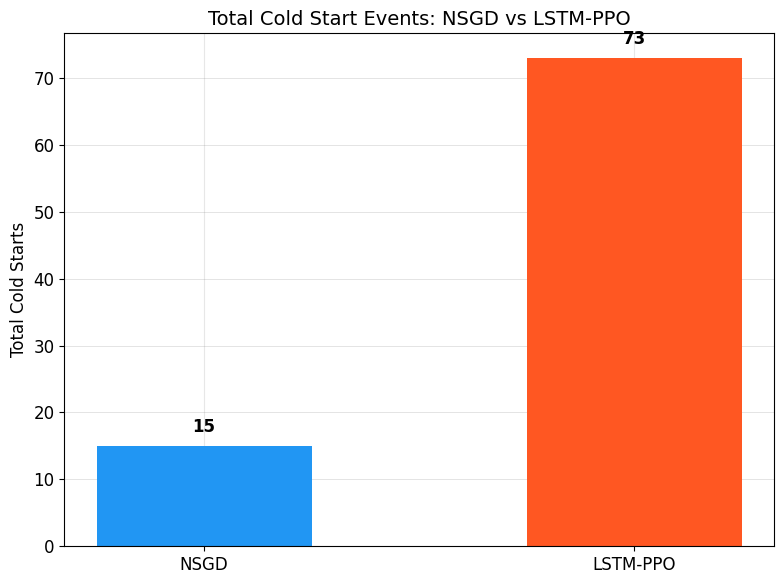

Duration: 92.7 minutes

NSGD:     1,318 requests, 15 cold starts (1.14%)
LSTM-PPO: 1,316 requests, 73 cold starts (5.55%)


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

nsgd_req = pd.read_csv('logs/nsgd_constant_poss_7_eval/request_log.csv')
ppo_req = pd.read_csv('logs/rl_eval/request_log.csv')

# Normalize to elapsed minutes since each run's start
nsgd_req['minutes'] = (nsgd_req['timestamp'] - nsgd_req['timestamp'].min()) / 60
ppo_req['minutes'] = (ppo_req['timestamp'] - ppo_req['timestamp'].min()) / 60

# Trim to shorter run for fair comparison
max_minutes = min(nsgd_req['minutes'].max(), ppo_req['minutes'].max())
nsgd_req = nsgd_req[nsgd_req['minutes'] <= max_minutes].copy()
ppo_req = ppo_req[ppo_req['minutes'] <= max_minutes].copy()

# Calculate total cold starts for the bars
nsgd_total_cold = nsgd_req['is_cold_start'].sum()
ppo_total_cold = ppo_req['is_cold_start'].sum()

# Create the columnar graph
fig, ax = plt.subplots(figsize=(8, 6))
models = ['NSGD', 'LSTM-PPO']
totals = [nsgd_total_cold, ppo_total_cold]
colors = ['#2196F3', '#FF5722'] 

bars = ax.bar(models, totals, color=colors, width=0.5)

# Formatting and labels
ax.set_ylabel('Total Cold Starts', fontsize=12)
ax.set_title('Total Cold Start Events: NSGD vs LSTM-PPO', fontsize=14)
ax.grid(axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

# Add the exact numerical values on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (max(totals)*0.02), int(yval), 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('logs/comparison/cold_start_total_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the final summary stats
print(f'Duration: {max_minutes:.1f} minutes\n')
print(f'NSGD:     {len(nsgd_req):,} requests, '
      f'{nsgd_total_cold} cold starts '
      f'({nsgd_req["is_cold_start"].mean() * 100:.2f}%)')
print(f'LSTM-PPO: {len(ppo_req):,} requests, '
      f'{ppo_total_cold} cold starts '
      f'({ppo_req["is_cold_start"].mean() * 100:.2f}%)')

In [5]:
nsgd_samples = pd.read_csv('logs/nsgd_constant_poss_7_eval/samples.csv')
ppo_samples = pd.read_csv('logs/rl_eval/samples.csv')
nsgd_req = pd.read_csv('logs/nsgd_constant_poss_7_eval/request_log.csv')
ppo_req = pd.read_csv('logs/rl_eval/request_log.csv')


print(f'NSGD:     {nsgd_samples["avg_execution_time"].mean():.3f}s '
      f'(median {nsgd_samples["avg_execution_time"].median():.3f}s)')
print(f'LSTM-PPO: {ppo_samples["avg_execution_time"].mean():.3f}s '
      f'(median {ppo_samples["avg_execution_time"].median():.3f}s)')
print()

print(f'NSGD:')
print(f'  mean:   {nsgd_req["latency_seconds"].mean() * 1000:.1f} ms')
#print(f'  median: {nsgd_req["latency_seconds"].median() * 1000:.1f} ms')
print()
print(f'LSTM-PPO:')
print(f'  mean:   {ppo_req["latency_seconds"].mean() * 1000:.1f} ms')
#print(f'  median: {ppo_req["latency_seconds"].median() * 1000:.1f} ms')


NSGD:     2.196s (median 1.898s)
LSTM-PPO: 1.886s (median 1.755s)

NSGD:
  mean:   2025.0 ms

LSTM-PPO:
  mean:   1652.2 ms
